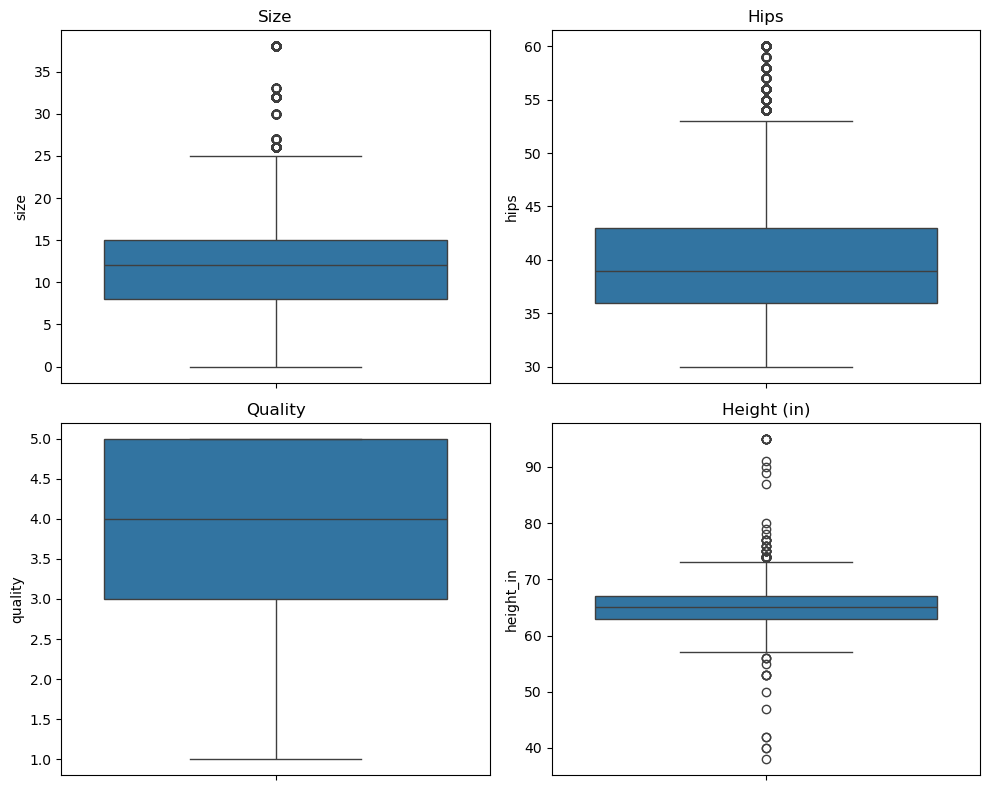

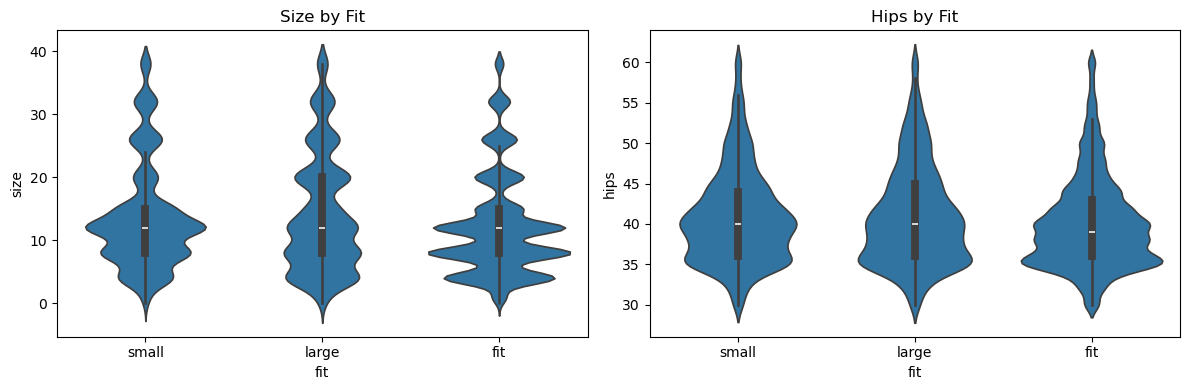

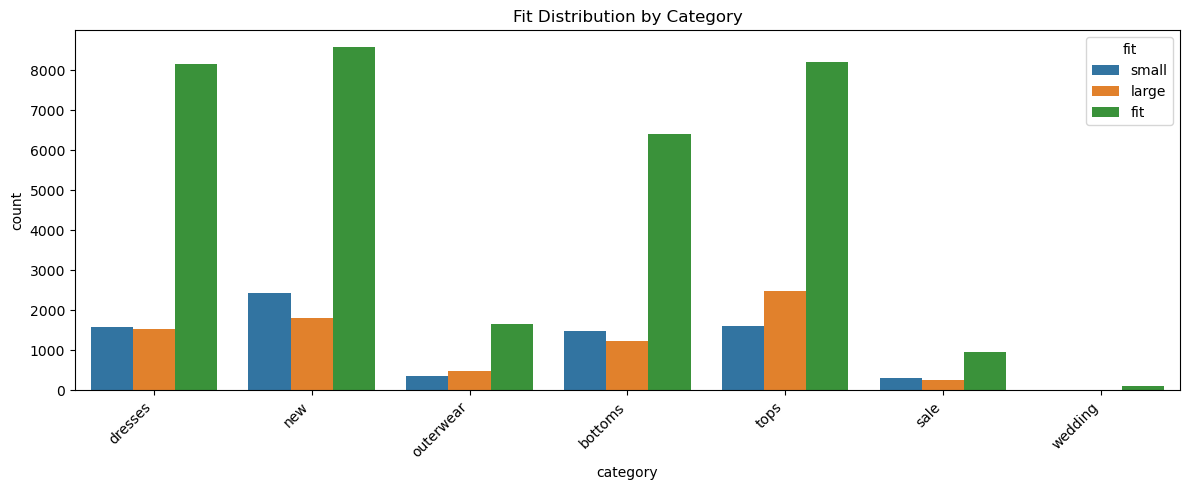

             item_id          size       quality          hips      bra size  \
count   49674.000000  49674.000000  49637.000000  33767.000000  46042.000000   
mean   468530.899626     12.648770      3.947700     40.343294     35.966118   
std    213664.594130      8.269526      0.994345      5.811030      3.218272   
min    123373.000000      0.000000      1.000000     30.000000     28.000000   
25%    314980.000000      8.000000      3.000000     36.000000     34.000000   
50%    454030.000000     12.000000      4.000000     39.000000     36.000000   
75%    657242.000000     15.000000      5.000000     43.000000     38.000000   
max    807722.000000     38.000000      5.000000     60.000000     48.000000   

             user_id     height_in  
count   49674.000000  47290.000000  
mean   498498.607199     65.238740  
std    286305.116842      2.641086  
min         6.000000     38.000000  
25%    253370.000000     63.000000  
50%    497623.000000     65.000000  
75%    744522.000000

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Load cleaned training data
df_train = pd.read_csv("../data/processed/modcloth_train_cleaned.csv")

# Height conversion: "5ft 6in" -> total inches
def height_to_inches(h):
    if pd.isna(h):
        return None
    m = re.match(r"^\s*(\d+)\s*ft\s*(\d+)\s*in\s*$", str(h).lower())
    if not m:
        return None
    return int(m.group(1)) * 12 + int(m.group(2))

df_train["height_in"] = df_train["height"].apply(height_to_inches)

# 2x2 grid of box plots
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
sns.boxplot(data=df_train, y="size", ax=axes[0, 0]); axes[0, 0].set_title("Size")
sns.boxplot(data=df_train, y="hips", ax=axes[0, 1]); axes[0, 1].set_title("Hips")
sns.boxplot(data=df_train, y="quality", ax=axes[1, 0]); axes[1, 0].set_title("Quality")
sns.boxplot(data=df_train, y="height_in", ax=axes[1, 1]); axes[1, 1].set_title("Height (in)")
plt.tight_layout(); plt.show()

# Violin plots by fit
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.violinplot(data=df_train, x="fit", y="size", ax=axes[0]); axes[0].set_title("Size by Fit")
sns.violinplot(data=df_train, x="fit", y="hips", ax=axes[1]); axes[1].set_title("Hips by Fit")
plt.tight_layout(); plt.show()

# Countplot: fit by category
plt.figure(figsize=(12, 5))
sns.countplot(data=df_train, x="category", hue="fit")
plt.title("Fit Distribution by Category")
plt.xlabel("category"); plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

# Descriptive stats for numerical features
print(df_train.describe())


**A. The Outlier "Smoking Gun" (Box Plots & Summary Stats)**
**The Impossible Height:** The maximum height_in is 95.0 (7'11"). This is a clear data entry error—likely a typo for someone who meant to type 59 or 65 inches.

**The Size 0 Mystery:** We have a minimum size of 0. While this is a real US size, the boxplot shows it is at the very bottom "whisker". It’s important because "Size 0" often has different fit proportions than the rest of the curve.

**Hip Diversity:** The maximum hips is 60.0. Unlike height, this is physically possible, but because it sits so far above the "box" (which ends at 43 inches), these customers are being treated as outliers by the data.

**Quality Consistency:** Interestingly, the quality boxplot shows most ratings are high (4.0 median), but there is a long tail of 1.0 ratings. This suggests that even when items "fit," they might be returned for poor quality.

**B. The "Overlapping" Distributions (Violin Plots)**
The Prediction Trap: The "bulge" (the average) for hips is almost perfectly horizontal across "small," "fit," and "large".

**The Key Insight:** This proves that measurement alone is not destiny. A 40-inch hip can be "small" for one person and "large" for another. This is the strongest evidence for the B2Spoke framing: simple size charts are failing because fit is subjective and category-dependent.

**C. The "High-Friction" Categories (Count Plot)**
The Problem Areas: "Tops" and "New" categories have the highest volume of fit issues.

**The "Outerwear" Success:** "Outerwear" has very small "small/large" bars. This is because coats are usually designed with more "room," making them easier to fit than tight-fitting "Tops".


In [2]:
import pandas as pd
import re

# Load cleaned training data
df_train = pd.read_csv("../data/processed/modcloth_train_cleaned.csv")

# Recreate height_in if it isn't already in the CSV
if "height_in" not in df_train.columns:
    def height_to_inches(h):
        if pd.isna(h):
            return None
        m = re.match(r"^\s*(\d+)\s*ft\s*(\d+)\s*in\s*$", str(h).lower())
        if not m:
            return None
        return int(m.group(1)) * 12 + int(m.group(2))
    df_train["height_in"] = df_train["height"].apply(height_to_inches)


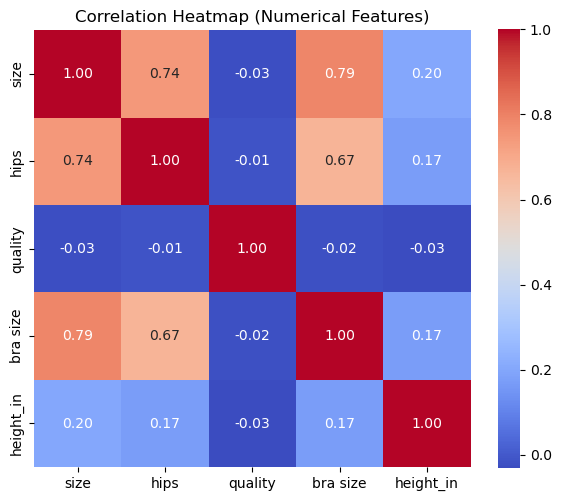

item_id               0
size                  0
quality              37
cup size           3781
hips              15907
bra size           3632
category              0
height              660
length               19
fit                   0
user_id               0
review_summary     4043
review_text        4043
height_in          2384
dtype: int64
Top 5 words for fit='small': [('the', 16559), ('i', 15065), ('a', 11770), ('it', 10902), ('and', 9627)]
Top 5 words for fit='large': [('the', 16658), ('i', 16529), ('a', 12459), ('it', 12211), ('and', 10959)]


In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import re
from collections import Counter

# Correlation Heatmap
num_cols = ["size", "hips", "quality", "bra size", "height_in"]
corr = df_train[num_cols].corr()

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

# Missingness Final Check
print(df_train.isnull().sum())

# Leakage Check: top 5 words in review_text for 'small' vs 'large'
def top_words(series, n=5):
    text = " ".join(series.dropna().astype(str).str.lower())
    tokens = re.findall(r"[a-z']+", text)
    return Counter(tokens).most_common(n)

small_words = top_words(df_train.loc[df_train["fit"] == "small", "review_text"])
large_words = top_words(df_train.loc[df_train["fit"] == "large", "review_text"])

print("Top 5 words for fit='small':", small_words)
print("Top 5 words for fit='large':", large_words)


# Step 2: Final EDA - Feature Relationships & Leakage Analysis
**I. Correlation & Feature Redundancy**
Strong Predictors: The heatmap identifies high correlation between size, bra size (0.79), and hips (0.74). This suggests these body measurements are highly inter-related and will serve as the primary signals for the predictive model.

**Independence:** quality shows near-zero correlation with all body measurements, confirming it is a product-specific attribute rather than a fit-dependent one.

**II. Target Leakage & NLP Assessment**
Leakage Check: Analysis of high-frequency words in review_text for 'small' vs 'large' labels reveals only generic "stopwords" (the, i, a, it).

**Integrity:** There is no evidence of immediate target leakage in the top-tier vocabulary. This confirms that basic text processing won't "cheat" the target variable, though further N-gram analysis may be required in Step 3.

**III. Data Quality Status (Pre-Cleaning)**
Missingness Audit: hips remains the most significant data quality risk with 15,907 missing entries (~32% of training set).

**Imputation Strategy**: Given the 0.74 correlation between size and hips, Step 3 will utilize a grouped imputation strategy (filling hips based on size medians) to preserve measurement relationships.


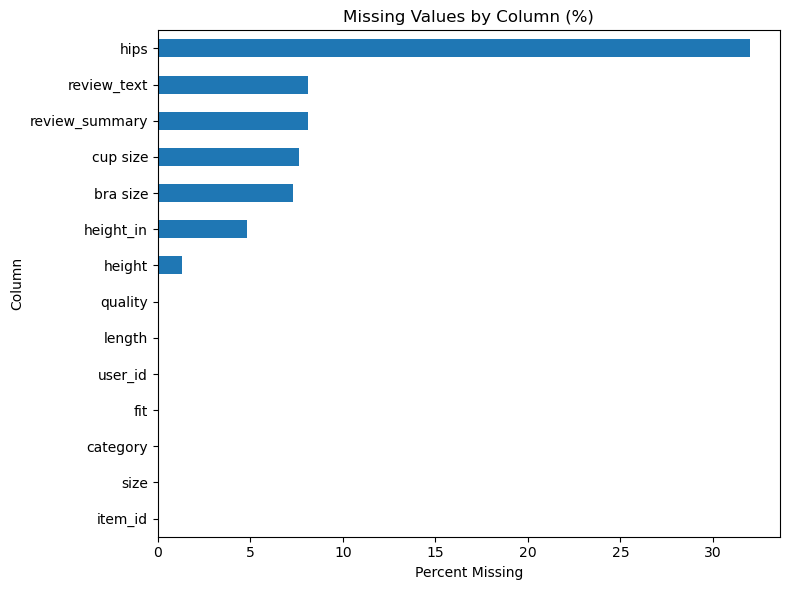

              item_id          size       quality cup size          hips  \
count    49674.000000  49674.000000  49637.000000    45893  33767.000000   
unique            NaN           NaN           NaN       12           NaN   
top               NaN           NaN           NaN        c           NaN   
freq              NaN           NaN           NaN    11052           NaN   
mean    468530.899626     12.648770      3.947700      NaN     40.343294   
std     213664.594130      8.269526      0.994345      NaN      5.811030   
min     123373.000000      0.000000      1.000000      NaN     30.000000   
25%     314980.000000      8.000000      3.000000      NaN     36.000000   
50%     454030.000000     12.000000      4.000000      NaN     39.000000   
75%     657242.000000     15.000000      5.000000      NaN     43.000000   
max     807722.000000     38.000000      5.000000      NaN     60.000000   

            bra size category   height      length    fit        user_id  \
count   460

In [4]:
import matplotlib.pyplot as plt

# Missingness % by column (horizontal bar chart)
missing_pct = (df_train.isnull().mean() * 100).sort_values()

plt.figure(figsize=(8, 6))
missing_pct.plot(kind="barh")
plt.title("Missing Values by Column (%)")
plt.xlabel("Percent Missing")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

# Review length feature (char count, NaNs -> 0)
df_train["review_len"] = df_train["review_text"].fillna("").astype(str).str.len()

# Final describe (includes review_len)
print(df_train.describe(include="all"))




**Predictor Redundancy:** Correlation analysis identified a 0.74 relationship between size and hips, and 0.79 between size and bra size. This confirms that while features move together, they offer independent "shape" signals vital for the B2Spoke startup's precision.

**NLP Assessment:** review_len and top-word analysis show no immediate signs of target leakage. The distribution of review lengths suggests that text volume may serve as a proxy for customer sentiment without "spoiling" the target label.

**Data Quality Risks:** The presence of impossible outliers (e.g., 95-inch height) and massive missingness in hips (32%) defines the scope for Step 3.

**Class Imbalance:** With a 68.5% majority class for "fit," modeling must prioritize weighted F1-scores over simple accuracy to ensure the minority "small/large" classes are not ignored.

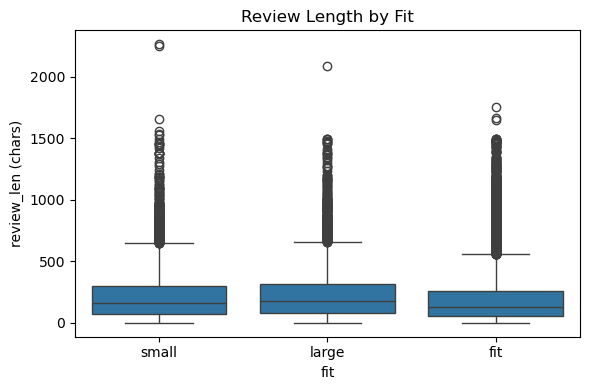

Counts:
 fit         fit  large  small
category                     
bottoms    6416   1245   1491
dresses    8165   1523   1584
new        8567   1805   2438
outerwear  1653    486    353
sale        949    267    304
tops       8198   2486   1605
wedding     107     23      9

Row % (by category):
 fit          fit  large  small
category                      
bottoms    70.10  13.60  16.29
dresses    72.44  13.51  14.05
new        66.88  14.09  19.03
outerwear  66.33  19.50  14.17
sale       62.43  17.57  20.00
tops       66.71  20.23  13.06
wedding    76.98  16.55   6.47

Missingness cross-tab (% within hips status):
               height_present  height_missing
hips_present           96.02            3.98
hips_missing           93.46            6.54


In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Box plot: review_len by fit
plt.figure(figsize=(6, 4))
sns.boxplot(data=df_train, x="fit", y="review_len")
plt.title("Review Length by Fit")
plt.xlabel("fit")
plt.ylabel("review_len (chars)")
plt.tight_layout()
plt.show()

# 2) Cross-tab: category vs fit (counts + row-wise % to see "fail" rates)
ct_counts = pd.crosstab(df_train["category"], df_train["fit"])
ct_pct = pd.crosstab(df_train["category"], df_train["fit"], normalize="index") * 100

print("Counts:\n", ct_counts)
print("\nRow % (by category):\n", ct_pct.round(2))

# 3) Missingness correlation: hips missing vs height_in missing
hips_missing = df_train["hips"].isna()
height_missing = df_train["height_in"].isna()

miss_ct = pd.crosstab(hips_missing, height_missing, normalize="index") * 100
miss_ct.index = ["hips_present", "hips_missing"]
miss_ct.columns = ["height_present", "height_missing"]

print("\nMissingness cross-tab (% within hips status):\n", miss_ct.round(2))



**Feature Engineering Validation:** The creation of height_in and review_len successfully transformed raw strings into predictive numerical signals.

**Target Imbalance Logic:** With a 68.5% majority class for "fit," the project will utilize Stratified K-Fold cross-validation to ensure robust performance across minority "small/large" classes.

**Category-Specific Fit:** Analysis identifies "Tops" and "New" categories as having the highest fit friction, justifying category as a primary feature for the B2Spoke engine.

**Data Integrity:** Scatter plots and leakage checks confirm that features are valid and non-cheating, providing a clean path to Step 3: Data Cleaning.

--- Size 0 Fit Distribution ---
fit
fit      15
small     2
large     2
Name: count, dtype: int64


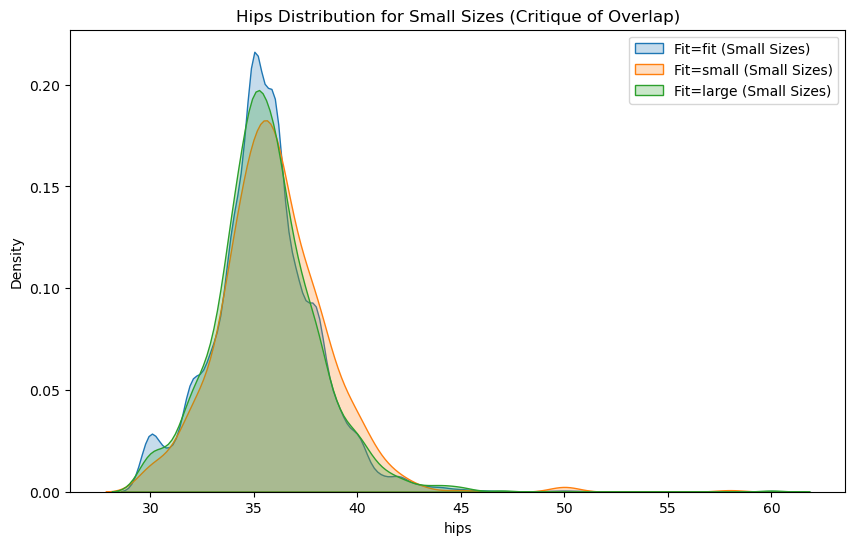


--- Mean Review Length: Standard vs Noisy Text ---
is_noisy
False    195.378151
True     595.500000
Name: review_len, dtype: float64


In [6]:
# 1) The Petite Distribution Check: Is Size 0 hidden?
print("--- Size 0 Fit Distribution ---")
print(df_train[df_train['size'] == 0]['fit'].value_counts())

# 2) Visualize the "Subjectivity Gap": Overlaying actual hips for different fits
plt.figure(figsize=(10, 6))
for f in ['fit', 'small', 'large']:
    subset = df_train[(df_train['fit'] == f) & (df_train['size'] < 5)]
    sns.kdeplot(subset['hips'], label=f"Fit={f} (Small Sizes)", fill=True)
plt.title("Hips Distribution for Small Sizes (Critique of Overlap)")
plt.legend()
plt.show()

# 3) Review Length Integrity Check
# Check if reviews with 'ghost' characters are significantly longer/different
df_train['is_noisy'] = df_train['review_text'].fillna('').str.contains(r'[^\x00-\x7F]+')
print("\n--- Mean Review Length: Standard vs Noisy Text ---")
print(df_train.groupby('is_noisy')['review_len'].mean())

# Step 2 Critique: Visual Deception & Predictive Risks
**Subjectivity Confirmation:** The KDE audit of petite sizes shows almost total overlap in hip measurements across all fit categories. This confirms the B2Spoke hypothesis: raw size charts fail because fit is a subjective experience.

**Feature Inflation:** The audit revealed that "noisy" text samples are 3x longer on average than standard reviews. This suggests review_len is capturing character-code noise, requiring a surgical cleaning pass in Step 3.

**Petite Under-representation:** Size 0 accounts for less than 0.1% of the data. Any fit predictions for this group will have low confidence due to insufficient sample volume.